# Part D: Data Preparation
Use the Brown corpus from NLTK. It is (1) directly available in NLTK, (2) already sentence-segmented, and (3) easy to convert into token IDs for a PyTorch RNN.

Dataset (single source for both Part A and Part B)

- NLTK Brown corpus, category: news
- NLTK access: nltk.corpus.brown.sents(categories='news')
- Output format: list of sentences, each sentence is a list of tokens
- Works cleanly for:
    - n-gram LM training and perplexity (NLTK)
    - sequence batching for RNN LM (PyTorch)

**Rule: Both tasks must use the exact same processed token stream, vocabulary, and data split.**

In [1]:
# Use the Brown corpus from NLTK Brown corpus, category: news
import nltk
from nltk.corpus import brown
# Download the Brown corpus if not already downloaded
nltk.download('brown')

# NLTK access: nltk.corpus.brown.sents(categories='news')
news_sentences = brown.sents(categories='news')

# Output format: list of sentences, each sentence is a list of tokens
print(news_sentences)

[['The', 'Fulton', 'County', 'Grand', 'Jury', 'said', 'Friday', 'an', 'investigation', 'of', "Atlanta's", 'recent', 'primary', 'election', 'produced', '``', 'no', 'evidence', "''", 'that', 'any', 'irregularities', 'took', 'place', '.'], ['The', 'jury', 'further', 'said', 'in', 'term-end', 'presentments', 'that', 'the', 'City', 'Executive', 'Committee', ',', 'which', 'had', 'over-all', 'charge', 'of', 'the', 'election', ',', '``', 'deserves', 'the', 'praise', 'and', 'thanks', 'of', 'the', 'City', 'of', 'Atlanta', "''", 'for', 'the', 'manner', 'in', 'which', 'the', 'election', 'was', 'conducted', '.'], ...]


[nltk_data] Downloading package brown to /Users/omotoyosi/nltk_data...
[nltk_data]   Package brown is already up-to-date!


### D0. Load and preprocess (one pipeline only)
1. Load sentences: brown.sents(categories='news')
2. Preprocess tokens:
    - lowercase
    - remove punctuation-only tokens (keep words like “don’t” as tokens)
    - keep stopwords (required for language modeling)
3. Add special tokens:
    - `<bos>` at the start of every sentence
    - `<eos>` at the end of every sentence
    - `<unk>` for unknown words (needed for PyTorch and for robust evaluation)

In [2]:
# Load sentences from the Brown corpus, category: news
news_sentences = brown.sents(categories='news')

# Preprocess the sentences: convert to lowercase and remove punctuation
import string
import re

_punct_only = re.compile(r"^\W+$")

def preprocess_sentence(sentence):
    # Convert to lowercase
    sentence = [word.lower() for word in sentence]
    # Remove punctuation
    sentence = [word for word in sentence if word not in string.punctuation and not _punct_only.match(word)]
    return sentence
preprocessed_sentences = [preprocess_sentence(sentence) for sentence in news_sentences]
print(preprocessed_sentences)

# Add special tokens for start <bos> and end <eos> of sentences and <unk> for unknown words
def add_special_tokens(sentence):
    return ['<bos>'] + sentence + ['<eos>']
sentences_with_special_tokens = [add_special_tokens(sentence) for sentence in preprocessed_sentences]
print(sentences_with_special_tokens)



[['the', 'fulton', 'county', 'grand', 'jury', 'said', 'friday', 'an', 'investigation', 'of', "atlanta's", 'recent', 'primary', 'election', 'produced', 'no', 'evidence', 'that', 'any', 'irregularities', 'took', 'place'], ['the', 'jury', 'further', 'said', 'in', 'term-end', 'presentments', 'that', 'the', 'city', 'executive', 'committee', 'which', 'had', 'over-all', 'charge', 'of', 'the', 'election', 'deserves', 'the', 'praise', 'and', 'thanks', 'of', 'the', 'city', 'of', 'atlanta', 'for', 'the', 'manner', 'in', 'which', 'the', 'election', 'was', 'conducted'], ['the', 'september-october', 'term', 'jury', 'had', 'been', 'charged', 'by', 'fulton', 'superior', 'court', 'judge', 'durwood', 'pye', 'to', 'investigate', 'reports', 'of', 'possible', 'irregularities', 'in', 'the', 'hard-fought', 'primary', 'which', 'was', 'won', 'by', 'mayor-nominate', 'ivan', 'allen', 'jr.'], ['only', 'a', 'relative', 'handful', 'of', 'such', 'reports', 'was', 'received', 'the', 'jury', 'said', 'considering', 'th

### D1. Split (same split used for both models)
Split by sentence (not by token) to avoid leakage:
- 80% train
- 10% validation
- 10% test

Report:
- number of sentences in each split
- number of tokens in each split
- vocabulary size (built from train only)

In [3]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [4]:
# Split by sentences, not token - 80% train, 10% validation, 10% test
import sklearn

from sklearn.model_selection import train_test_split

In [5]:
# random.seed(42)
# random.shuffle(processed_sents)

# total_sentences = len(processed_sents)
# train_end = int(0.8 * total_sentences)
# val_end = int(0.9 * total_sentences)

# train_sents = processed_sents[:train_end]
# val_sents = processed_sents[train_end:val_end]
# test_sents = processed_sents[val_end:]

train_sents, temp_sents = train_test_split(sentences_with_special_tokens, test_size=0.2, random_state=42)
val_sents, test_sents = train_test_split(temp_sents, test_size=0.5, random_state=42)    
print(f'Training sentences: {len(train_sents)}')
print(f'Validation sentences: {len(val_sents)}')
print(f'Test sentences: {len(test_sents)}')


Training sentences: 3698
Validation sentences: 462
Test sentences: 463


In [6]:
def num_tokens(slist: list[list[str]]) -> int:
    return sum(len(s) for s in slist)

print("Train:", len(train_sents), "sentences |", num_tokens(train_sents), "tokens")
print("Val  :", len(val_sents),   "sentences |", num_tokens(val_sents),   "tokens")
print("Test :", len(test_sents),  "sentences |", num_tokens(test_sents),  "tokens")

Train: 3698 sentences | 77859 tokens
Val  : 462 sentences | 9958 tokens
Test : 463 sentences | 10021 tokens


### D2. Vocabulary (shared)
Build vocabulary from training split only with:
- min_freq (e.g., 2 or 3)
- all other words map to `<unk>`

Report:
- chosen min_freq
- final vocab size
- top 20 most frequent tokens

In [7]:
# Build vocabulary from training split only - minimum frequency of 2, and add <unk> token for unknown words
from collections import Counter
from itertools import chain
min_freq = 3
def build_vocabulary(sentences, min_freq=min_freq):
    word_counts = Counter(chain.from_iterable(sentences))
    # Filter out words that occur less than min_freq times
    vocab = {word for word, count in word_counts.items() if count >= min_freq}
    # Add <unk> token for unknown words
    vocab.add('<unk>')
    return vocab
vocabulary = build_vocabulary(train_sents, min_freq=min_freq)

# Print min_freq, final vocabulary size, and top 20 most frequent tokens
print(f'Minimum frequency: {min_freq}')
print(f'Vocabulary sample: {list(vocabulary)[:20]}')
print(f'Final vocabulary size: {len(vocabulary)}')
print(f'Top 20 most frequent tokens: {Counter(chain.from_iterable(train_sents)).most_common(20)}')
# print unk id
# vocab_list = sorted(vocabulary)  # Sort vocabulary for consistent ordering
# unk_id = vocab_list.index('<unk>')
# print(f'<unk> token ID: {unk_id}')


Minimum frequency: 3
Vocabulary sample: ['patricia', 'talks', 'k.', 'taxpayers', 'clint', 'introduced', 'petitions', 'plains', 'relatively', 'developed', 'served', 'flavor', '75', 'masters', 'lawrence', 'specific', 'wants', 'olivetti', 'levels', '1949']
Final vocabulary size: 3552
Top 20 most frequent tokens: [('the', 5052), ('<bos>', 3698), ('<eos>', 3698), ('of', 2272), ('and', 1757), ('a', 1690), ('to', 1669), ('in', 1600), ('for', 780), ('that', 667), ('was', 588), ('is', 584), ('on', 551), ('at', 521), ('he', 509), ('with', 445), ('be', 424), ('as', 415), ('by', 396), ('it', 372)]


# Part A – Statistical n-gram Language Model (OPTIONAL)

Build and evaluate a trigram language model using existing Python libraries. In this section, you must use NLTK or another established Python library for n-gram modeling. You are NOT required to implement n-gram counting or probability estimation from scratch.

You may use:
- nltk.lm (recommended)
- nltk.util.ngrams
- collections.Counter
- Any built-in smoothing utilities provided by NLTK

Your focus should be on:
- Understanding how n-gram models work
- Applying smoothing correctly
- Interpreting perplexity
- Analyzing results


**A1. Train a Trigram Language Model**

Using NLTK’s language modeling tools:

Train a trigram model:

You may use one of the following:
- MLE (Maximum Likelihood Estimation)
- Laplace (Add-1 smoothing)
- Lidstone (Add-k smoothing)

Report:
- Which model you used
- Which smoothing method (if any)
- Why smoothing is necessary


In [8]:
# Using NLTK’s language modeling tools, train a trigram model using one of the following: MLE, Laplace (Add-1 smoothing) or Lidstone (Add-k smoothing)
# from nltk.lm import Laplace
# from nltk.lm.preprocessing import padded_everygram_pipeline
# # Prepare the data for language modeling
# train_data, padded_vocab = padded_everygram_pipeline(3, train_sentences)
# # Train a trigram model with Laplace smoothing
# model = Laplace(3)
# model.fit(train_data, padded_vocab)

# from nltk.lm import Laplace
# from nltk.util import ngrams

# n = 3 # Trigram model

# # 1. Convert sentences into lists of trigrams
# train_ngrams = [list(ngrams(sent, n)) for sent in train_sents]

# # 2. Initialize and Train the Model
# # We use Laplace smoothing to avoid zero probabilities for unseen n-grams
# model = Laplace(n)

# # Fit the model using your generated trigrams and the shared vocabulary from Part D
# model.fit(train_ngrams, vocabulary)

In [ ]:
from nltk.lm import Laplace
from nltk.util import everygrams, ngrams

n = 3 # Max n-gram length (unigrams, bigrams, trigrams)

# 1. Convert sentences into everygrams (1-grams, 2-grams, AND 3-grams)
# We set max_len=3 so it doesn't generate massive n-grams
train_ngrams = [list(everygrams(sent, max_len=n)) for sent in train_sents]

# 2. Initialize and Train the Model
model = Laplace(n) # Using Laplace (Add-1 smoothing)
model.fit(train_ngrams, vocabulary)

Trigram model from NLTK library was used with Laplace Add-1 smoothing. 

It adds 1 to the count of every n-gram, so that there's no value with zero probability. 

Smoothing is used to avoid zero probabilities for unseen n-grams.

**A2. Evaluate with Perplexity**

Compute perplexity on the validation and test set.

Report:

- Validation and test perplexity
- Interpretation: Is it high or low relative to your expectations?
- What factors affect perplexity?


In [10]:
# Convert validation and test sentences to trigrams
val_ngrams = [list(ngrams(sent, n)) for sent in val_sents]
test_ngrams = [list(ngrams(sent, n)) for sent in test_sents]

# Flatten the lists of lists into a single stream of trigrams for evaluation
flat_val_ngrams = [ngram for sent in val_ngrams for ngram in sent]
flat_test_ngrams = [ngram for sent in test_ngrams for ngram in sent]

# Calculate and report perplexity
val_perplexity = model.perplexity(flat_val_ngrams)
test_perplexity = model.perplexity(flat_test_ngrams)

print(f"Validation Perplexity: {val_perplexity}")
print(f"Test Perplexity: {test_perplexity}")

Validation Perplexity: 2029.087327675488
Test Perplexity: 1991.8454814442898


Validation perplexity is 2029.09, while Test perplexity is 1991.85. 

Even though test perplexity is lower, both perplexities have very high values. However, the high perplexity is expected for Laplace smoothing on a small dataset, as it dilutes probability mass across a massive number of unseen combinations. The model is as confused as if it had to choose uniformly between 2000 words at each step, reflecting the limitations of a 3-word context window on a diverse corpus.

Vocabulary size, n-gram order, smoothing technique, and the quality of the training data all play a role in determining perplexity.

**A4. Text Generation**

Generate 3 short text samples (at least 30 tokens each).

Briefly comment:
- Are they grammatical?
- Are they coherent?
- What limitations do you observe?


In [11]:
# Generate 3 samples
for i in range(3):
    # Generate 30 tokens, seeding the start with your <bos> token
    generated_tokens = model.generate(30, text_seed=['<bos>'])
    
    # Join tokens into a readable string
    generated_text = ' '.join(generated_tokens)
    print(f"Sample {i+1}: {generated_text}\n")

Sample 1: to appreciate the special <UNK> of cotton makes cleaning and <UNK> <eos> groups such as mrs. <UNK> <UNK> woman broke the <UNK> ball to short which robinson cut across age

Sample 2: having hit one of their big week <UNK> murray <UNK> reported <eos> the rising need for lifetime reading is apparent <eos> who plays golf with a sports background is generally

Sample 3: best bet for tonight that <UNK> grocery and variety stores be allowed <eos> <bos> in laos <eos> <UNK> glove into center <eos> <UNK> manner in which we now <UNK> <eos>



The sentences seem to try to follow a grammatical order, however, they are not coherent and have a lot of the `<bos>`, `<eos>` and `<UNK>` tokens. 

The limitations here are the lack of global coherence, despite high local grammatical correctness (3-word windows), "sparsity problem" (many valid word combinations never appear in the training data) and a lack of long-term memory.

# AIG230 – Assignment 6 (Part B Starter Notebook)
## Neural Language Model with PyTorch (RNN) – Student Version

This notebook covers **all of Part B**:

- **B1** Numericalization + training examples  
- **B2** Build an RNN Language Model  
- **B3** Train + validate (loss + perplexity)  
- **B4** Test perplexity + text generation  

### Dataset (same as Part A)
- **NLTK Brown corpus**, category: `news`

### Important
This is a **starter notebook**. You must complete the **TODO** blocks.  
Do not delete TODO comments. Add your code underneath them.


In [12]:
# ===== 1) Setup =====
import re
import math
import random
from collections import Counter
from dataclasses import dataclass
from typing import List, Dict, Tuple

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import nltk
from nltk.corpus import brown

# Download if needed (safe to run multiple times)
nltk.download('brown')

# Reproducibility (optional)
random.seed(42)
torch.manual_seed(42)

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print("Device:", device)

# Check for MPS (Apple Silicon GPU), then CUDA (NVIDIA), then default to CPU
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: mps


[nltk_data] Downloading package brown to /Users/omotoyosi/nltk_data...
[nltk_data]   Package brown is already up-to-date!


In [13]:
# ===== 2) Configuration (edit if needed) =====
# You can edit these hyperparameters as needed. The defaults should work for a basic run.
# This are not fixed rules, just a starting point. Feel free to experiment with different values!
# This parameter class is just a convenient way to store all the settings in one place. You can also use a dictionary or command-line arguments if you prefer.
# These parameters define the dataset category, how to split the data, vocabulary cutoff, model architecture, and training settings. Adjusting these can affect the performance and training time of your model.
@dataclass
class Config:
    category: str = "news"
    train_ratio: float = 0.80
    val_ratio: float = 0.10
    test_ratio: float = 0.10

    min_freq: int = 3       # vocab cutoff (train only)
    seq_len: int = 30       # T
    batch_size: int = 32

    emb_dim: int = 128
    hid_dim: int = 256
    num_layers: int = 1
    dropout: float = 0.0    # use 0.0 if num_layers == 1

    lr: float = 1e-3 
    epochs: int = 5
    grad_clip: float = 1.0  # optional but recommended

cfg = Config()

SPECIAL = {"BOS": "<bos>", "EOS": "<eos>", "UNK": "<unk>"}


# 3) Load + preprocess Brown (shared rules)

Preprocessing rules:
- lowercase
- remove punctuation-only tokens
- keep stopwords
- add `<bos>` and `<eos>` to each sentence


In [14]:
# ===== 3) Load Brown sentences =====
# This section loads the raw sentences from the Brown corpus, preprocesses them by lowercasing and removing punctuation-only tokens, and adds special tokens for the beginning and end of sentences. The resulting `sents` variable is a list of tokenized sentences ready for building the vocabulary and training the model.
# raw_sents: List[List[str]] = brown.sents(categories=cfg.category)
# print("Raw sentences:", len(raw_sents))
# print("Example raw:", raw_sents[0][:20])

# _punct_only = re.compile(r"^\W+$")

# def preprocess_sentence(tokens: List[str]) -> List[str]:
#     out = []
#     for tok in tokens:
#         tok = tok.lower()
#         if _punct_only.match(tok):
#             continue
#         out.append(tok)
#     return [SPECIAL["BOS"], *out, SPECIAL["EOS"]]

# sents = [preprocess_sentence(s) for s in raw_sents]
# print("Example preprocessed:", sents[0][:25])


# 4) Split train/val/test (by sentence)

Split by sentence to avoid leakage.


In [15]:
# ===== 4) Split =====
# This section splits the preprocessed sentences into training, validation, and test sets based on the specified ratios in the configuration. It also defines a helper function to count the total number of tokens in each split and prints out the number of sentences and tokens for each set.
# n = len(sents)
# n_train = int(cfg.train_ratio * n)
# n_val = int(cfg.val_ratio * n)
# n_test = n - n_train - n_val

# train_sents = sents[:n_train]
# val_sents = sents[n_train:n_train+n_val]
# test_sents = sents[n_train+n_val:]

# def num_tokens(slist: List[List[str]]) -> int:
#     return sum(len(s) for s in slist)

# print("Train:", len(train_sents), "sentences |", num_tokens(train_sents), "tokens")
# print("Val  :", len(val_sents),   "sentences |", num_tokens(val_sents),   "tokens")
# print("Test :", len(test_sents),  "sentences |", num_tokens(test_sents),  "tokens")


# 5) Build vocabulary (train only)

Words with frequency `< min_freq` become `<unk>`.


In [16]:
# ===== 5) Vocabulary =====
# This section builds the vocabulary from the training sentences by counting the frequency of each token and including only those that meet the minimum frequency threshold specified in the configuration. 
# It also creates mappings from tokens to indices (`stoi`) and from indices to tokens (`itos`), and prints out some statistics about the vocabulary and the most common tokens in the training set.
train_tokens = [tok for sent in train_sents for tok in sent]
counts = Counter(train_tokens)

itos = [SPECIAL["BOS"], SPECIAL["EOS"], SPECIAL["UNK"]]
stoi: Dict[str, int] = {tok: i for i, tok in enumerate(itos)}

for tok, c in counts.most_common():
    if tok in stoi:
        continue
    if c >= cfg.min_freq:
        stoi[tok] = len(itos)
        itos.append(tok)

vocab_size = len(itos)
unk_id = stoi[SPECIAL["UNK"]]

print("min_freq:", cfg.min_freq)
print("vocab_size:", vocab_size)
print("UNK id:", unk_id)
print("\nTop 15 tokens (train):")
for tok, c in counts.most_common(15):
    print(f"{tok:>12}  {c}")


min_freq: 3
vocab_size: 3552
UNK id: 2

Top 15 tokens (train):
         the  5052
       <bos>  3698
       <eos>  3698
          of  2272
         and  1757
           a  1690
          to  1669
          in  1600
         for  780
        that  667
         was  588
          is  584
          on  551
          at  521
          he  509


# 6) B1 – Numericalize + create training examples (Option 1)

You will:
1) Convert each sentence into token IDs  
2) Concatenate into one long stream per split  
3) Build a Dataset that returns:
- `x = stream[i : i+T]`
- `y = stream[i+1 : i+T+1]`

Complete the TODO blocks below.


In [17]:
# ===== 6.1) Numericalize (TODO) =====
# This function converts a list of tokens into a list of corresponding token IDs using the `stoi` mapping. 
# If a token is not found in the vocabulary, it uses the `unk_id` to represent it. This step is essential for preparing the data to be fed into the model, as models typically work with numerical representations of text.
# Why this is neccessary? Models cannot process raw text; they require numerical input. By converting tokens to their corresponding IDs, we can efficiently represent the text data in a format suitable for training neural networks. This also allows us to handle out-of-vocabulary tokens gracefully using the `unk_id`.
# How this connect to the embedding layer? The embedding layer takes token IDs as input and maps them to dense vector representations (embeddings). 
# By numericalizing the sentences, we can feed these token IDs into the embedding layer, which will then produce the corresponding embeddings for each token. This is a crucial step in the pipeline, as it allows us to convert raw text into a format that can be processed by the neural network.
def numericalize_sentence(tokens: List[str], stoi: Dict[str, int], unk_id: int) -> List[int]:
    # TODO: return list of token IDs for this sentence
    # Hint: use stoi.get(tok, unk_id)
    return [stoi.get(tok, unk_id) for tok in tokens]
    raise NotImplementedError

train_ids_sents = [numericalize_sentence(s, stoi, unk_id) for s in train_sents]
val_ids_sents   = [numericalize_sentence(s, stoi, unk_id) for s in val_sents]
test_ids_sents  = [numericalize_sentence(s, stoi, unk_id) for s in test_sents]

print("Example tokens:", train_sents[0][:12])
print("Example ids   :", train_ids_sents[0][:12])


Example tokens: ['<bos>', 'by', 'winning', 'against', 'bradley', 'kentucky', 'and', 'notre', 'dame', 'on', 'those', "teams'"]
Example ids   : [0, 19, 885, 91, 2649, 2, 5, 1690, 1691, 13, 120, 2]


In [18]:
# ===== 6.2) Build streams =====
train_stream = [tid for sent in train_ids_sents for tid in sent]
val_stream   = [tid for sent in val_ids_sents   for tid in sent]
test_stream  = [tid for sent in test_ids_sents  for tid in sent]

print("Train stream length:", len(train_stream))
print("Val   stream length:", len(val_stream))
print("Test  stream length:", len(test_stream))


Train stream length: 77859
Val   stream length: 9958
Test  stream length: 10021


In [19]:
# ===== 6.3) Dataset (TODO) =====
class NextTokenStreamDataset(Dataset):
    def __init__(self, token_stream: List[int], seq_len: int):
        self.stream = token_stream
        self.T = seq_len

    def __len__(self) -> int:
        # TODO: return number of examples in this stream
        # Need T tokens for x and 1 extra token for y shift.
        return len(self.stream) - self.T - 1
        raise NotImplementedError

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        # TODO: create x and y slices, convert to torch.long tensors
        # x: stream[idx : idx+T]
        # y: stream[idx+1 : idx+T+1]
        x = torch.tensor(self.stream[idx : idx+self.T], dtype=torch.long)
        y = torch.tensor(self.stream[idx+1 : idx+self.T+1], dtype=torch.long)
        return x, y
        raise NotImplementedError

train_ds = NextTokenStreamDataset(train_stream, cfg.seq_len)
val_ds   = NextTokenStreamDataset(val_stream,   cfg.seq_len)
test_ds  = NextTokenStreamDataset(test_stream,  cfg.seq_len)

print("Train examples:", len(train_ds))


Train examples: 77828


In [20]:
# ===== 6.4) DataLoaders + sanity check (run after TODOs are done) =====
train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False, drop_last=True)
test_loader  = DataLoader(test_ds,  batch_size=cfg.batch_size, shuffle=False, drop_last=True)

x_batch, y_batch = next(iter(train_loader))
print("x_batch shape:", x_batch.shape)  # expected: (B, T)
print("y_batch shape:", y_batch.shape)  # expected: (B, T)
print("x_batch dtype:", x_batch.dtype)

print("First 10 x:", x_batch[0][:10].tolist())
print("First 10 y:", y_batch[0][:10].tolist()) 


x_batch shape: torch.Size([32, 30])
y_batch shape: torch.Size([32, 30])
x_batch dtype: torch.int64
First 10 x: [52, 2467, 33, 2, 15, 22, 1, 0, 2, 19]
First 10 y: [2467, 33, 2, 15, 22, 1, 0, 2, 19, 2]


# 7) B2 – Build the RNN Language Model

Model requirements:
- Embedding layer
- RNN layer (`nn.RNN`)
- Linear layer to vocab size

Complete the TODO blocks.


In [21]:
# ===== 7) Model (TODO) =====
# Configuration class is defined at the top of the notebook. You can adjust the hyperparameters there as needed.
class RNNLanguageModel(nn.Module):
    def __init__(self, vocab_size: int, emb_dim: int, hid_dim: int, num_layers: int = 1, dropout: float = 0.0):
        super().__init__()
        # TODO: define embedding layer
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        
        # TODO: define RNN layer (batch_first=True)
        self.rnn = nn.RNN(emb_dim, hid_dim, num_layers=num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        #self.rnn = nn.LSTM(emb_dim, hid_dim, num_layers=num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        
        # TODO: define output projection layer (hid_dim -> vocab_size)
        self.linear = nn.Linear(hid_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, T) token IDs
        # Return logits: (B, T, V)
        # TODO: embed -> rnn -> linear
        emb = self.dropout(self.embedding(x))  # (B, T, E) means batch size, sequence length, embedding dimension
        rnn_out, _ = self.rnn(emb)             # (B, T, H) the second output is the final hidden state, which we don't need for language modeling
        logits = self.linear(rnn_out)          # (B, T, V) V is vocab size
        return logits
        raise NotImplementedError

# Instantiate model (after TODOs)
model = RNNLanguageModel(
    vocab_size=vocab_size,
    emb_dim=cfg.emb_dim,
    hid_dim=cfg.hid_dim,
    num_layers=cfg.num_layers,
    dropout=cfg.dropout
).to(device)

# Parameter count
num_params = sum(p.numel() for p in model.parameters())
print("Model parameters:", num_params)


Model parameters: 1466336


In [ ]:
# Chosen hyperparameters
print("Chosen hyperparameters:")
print("embedding dimension:", cfg.emb_dim)  #128
print("hidden dimension:", cfg.hid_dim)     #256
print("number of layers:", cfg.num_layers)  #1
print("learning rate:", cfg.lr)             #1e-3
print("sequence length:", cfg.seq_len)      #30

**Chosen hyperparameters**

Embedding dimension: 128

Hidden dimension: 256

Number of layers: 1

Learning rate: 1e-3

Sequence length: 30

# 8) B3 – Training + validation (loss + perplexity)

You will:
- Define loss (`CrossEntropyLoss`)
- Train for several epochs
- Compute validation perplexity

Complete the TODO blocks.


In [22]:
# ===== 8.1) Loss + optimizer (TODO) =====
# For language modeling with logits of shape (B, T, V),
# CrossEntropyLoss expects (N, V) logits and (N,) targets.
# TODO: set nn.CrossEntropyLoss()
criterion = nn.CrossEntropyLoss()  

# TODO: set torch.optim.Adam(model.parameters(), lr=cfg.lr)
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)

print("Ready (criterion, optimizer):", criterion is not None, optimizer is not None)


Ready (criterion, optimizer): True True


In [23]:
# ===== 8.2) Helper: compute perplexity (TODO) =====
@torch.no_grad()
def evaluate_perplexity(model: nn.Module, loader: DataLoader) -> float:
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        # TODO:
        # 1) logits = model(x) -> (B, T, V)
        logits = model(x)  # (B, T, V)
        
        # 2) reshape logits to (B*T, V)
        logits = logits.reshape(-1, logits.size(-1))  # (B*T, V)
        
        # 3) reshape y to (B*T,)
        y = y.reshape(-1)  # (B*T,)
        
        # 4) loss = criterion(...)
        loss = criterion(logits, y)
        
        # 5) accumulate total_loss weighted by number of tokens
        total_loss += loss.item() * y.size(0)
        total_tokens += y.size(0)

    avg_loss = total_loss / max(total_tokens, 1)
    ppl = math.exp(avg_loss)
    return ppl


In [24]:
# ===== 8.3) Training loop (TODO) =====
def train_one_epoch(model: nn.Module, loader: DataLoader) -> float:
    model.train()
    running_loss = 0.0
    running_tokens = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        # TODO:
        # 1) optimizer.zero_grad()
        optimizer.zero_grad()
        # 2) logits = model(x)
        logits = model(x)
        # 3) reshape logits/y for CrossEntropyLoss
        logits = logits.reshape(-1, logits.size(-1))  # (B*T, V)
        y = y.reshape(-1)  # (B*T,)
        # 4) loss.backward()
        loss = criterion(logits, y)
        loss.backward()
        # 5) optional: clip gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        # 6) optimizer.step()
        optimizer.step()
        # 7) accumulate running_loss weighted by number of tokens
        running_loss += loss.item() * y.size(0)
        running_tokens += y.size(0)

    return running_loss / max(running_tokens, 1)

train_losses = []
val_ppls = []

for epoch in range(1, cfg.epochs + 1):
    train_loss = train_one_epoch(model, train_loader)
    val_ppl = evaluate_perplexity(model, val_loader)

    train_losses.append(train_loss)
    val_ppls.append(val_ppl)

    print(f"Epoch {epoch:02d} | train loss: {train_loss:.4f} | val ppl: {val_ppl:.2f}")

    # Save after the first epoch to capture the best generalization
    if epoch == 2:
        # Move to CPU for portability, then save
        torch.save(model.to('cpu').state_dict(), 'rnn_model_epoch2.pth')
        # Move back to your Mac's GPU to continue training if desired
        model.to(device)
        print("Model state saved after Epoch 2.")


Epoch 01 | train loss: 3.5759 | val ppl: 239.96
Epoch 02 | train loss: 1.5177 | val ppl: 802.02
Model state saved after Epoch 2.
Epoch 03 | train loss: 0.8795 | val ppl: 1990.91
Epoch 04 | train loss: 0.6499 | val ppl: 3785.27
Epoch 05 | train loss: 0.5449 | val ppl: 6075.89


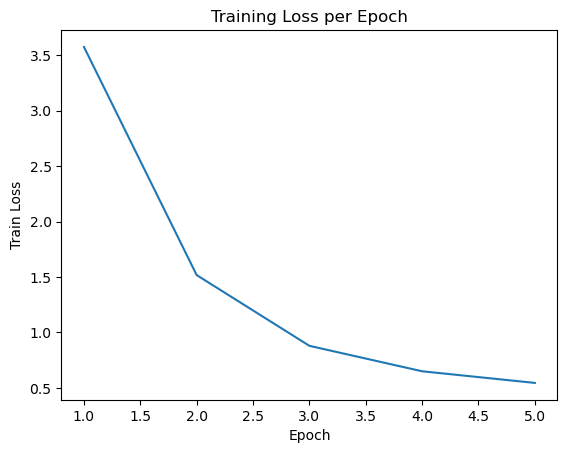

In [25]:
# ===== 8.4) Plot training loss (optional) =====
import matplotlib.pyplot as plt

plt.figure()
plt.plot(range(1, len(train_losses)+1), train_losses)
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Training Loss per Epoch")
plt.show()


In [26]:
# # Another model with different hyperparameters
# model2 = RNNLanguageModel(
#     vocab_size=vocab_size,
#     emb_dim=64,  # Reduced embedding dimension
#     hid_dim=128,  # Reduced hidden dimension
#     num_layers=2,  # Increased number of layers
#     dropout=0.2  # Added dropout for regularization   
# ).to(device)

# # Parameter count
# num_params2 = sum(p.numel() for p in model2.parameters())
# print("Model2 parameters:", num_params2)

In [27]:
# # Re-initialize optimizer for the new model
# optimizer = torch.optim.Adam(model2.parameters(), lr=0.0001)  # Reduced learning rate

# # Train the new model
# train_losses2 = []
# val_ppls2 = []

# print("\nModel 2 training with different hyperparameters")
# for epoch in range(1, cfg.epochs + 1):
#     train_loss2 = train_one_epoch(model2, train_loader)
#     val_ppl2 = evaluate_perplexity(model2, val_loader)

#     train_losses2.append(train_loss2)
#     val_ppls2.append(val_ppl)

#     print(f"Epoch {epoch:02d} | train loss: {train_loss:.4f} | val ppl: {val_ppl:.2f}")

In [28]:
# ===== 8.4) Plot training loss (optional) =====
# import matplotlib.pyplot as plt

# plt.figure()
# plt.plot(range(1, len(train_losses)+1), train_losses)
# plt.xlabel("Epoch")
# plt.ylabel("Train Loss")
# plt.title("Training Loss per Epoch (Model 2)")
# plt.show()

# 9) B4 – Test perplexity + text generation

You will:
- Report test perplexity
- Generate text by sampling from the model

Complete the TODO blocks.


In [29]:
# 1. Re-instantiate the model with your exact hyperparameters
#model = RNNLanguageModel(vocab_size, emb_dim, hid_dim, num_layers)

model_epoch_2 = RNNLanguageModel(
    vocab_size=vocab_size,
    emb_dim=cfg.emb_dim,
    hid_dim=cfg.hid_dim,
    num_layers=cfg.num_layers,
    dropout=cfg.dropout
)

# 2. Load the weights (ensure the file is in your working directory)
model_epoch_2.load_state_dict(torch.load('rnn_model_epoch2.pth', weights_only=True))

# 3. Move to device and set to evaluation mode
model_epoch_2.to(device)
model_epoch_2.eval()

RNNLanguageModel(
  (embedding): Embedding(3552, 128)
  (rnn): RNN(128, 256, batch_first=True)
  (linear): Linear(in_features=256, out_features=3552, bias=True)
  (dropout): Dropout(p=0.0, inplace=False)
)

In [ ]:
# ===== 9.1) Test perplexity =====
test_ppl_epoch_2 = evaluate_perplexity(model_epoch_2, test_loader)  # will work after TODOs done
print("Test perplexity after Epoch 2:", test_ppl_epoch_2)

test_ppl = evaluate_perplexity(model, test_loader)  # will work after TODOs done
print("Final test perplexity after Epoch 5:", test_ppl)

Test perplexity after Epoch 2: 758.5005938670714
Test perplexity after Epoch 5: 5625.508178266127


In [ ]:
# ===== 9.2) Text generation (TODO) =====
# We will generate tokens one-by-one:
# - Start with <bos>
# - Predict next token distribution
# - Sample (or argmax)
# - Append token and continue

def sample_next_token(logits_1v: torch.Tensor, temperature: float = 1.0) -> int:
    # logits_1v: (V,) logits for next token
    # TODO:
    # 1) divide logits by temperature
    logits_1v = logits_1v / temperature
    # 2) convert to probabilities (softmax)
    probs = torch.softmax(logits_1v, dim=-1)
    # 3) sample an index using torch.multinomial
    next_token_id = torch.multinomial(probs, num_samples=1).item()
    return next_token_id

@torch.no_grad()
def generate_text(model: nn.Module, stoi: Dict[str, int], itos: List[str],
                  max_new_tokens: int = 50, temperature: float = 1.0) -> str:
    model.eval()

    bos_id = stoi[SPECIAL["BOS"]]
    eos_id = stoi[SPECIAL["EOS"]]

    # Start sequence with <bos>
    generated = [bos_id]

    for _ in range(max_new_tokens):
        # TODO:
        # 1) create input tensor x of shape (1, current_len)
        x = torch.tensor(generated, dtype=torch.long).unsqueeze(0).to(device)  # (1, current_len)
        # 2) logits = model(x) -> (1, current_len, V)
        logits = model(x)  # (1, current_len, V)
        # 3) take last timestep logits: logits[0, -1, :]
        logits_1v = logits[0, -1, :]  # (V,)
        # 4) sample next token id
        next_token_id = sample_next_token(logits_1v, temperature=temperature)
        # 5) append; break if eos
        generated.append(next_token_id)
        if next_token_id == eos_id:
            break

    # Convert ids to tokens and return as a string
    tokens = [itos[i] for i in generated]
    return " ".join(tokens)

print("Generated texts after Epoch 2:")
# print 3 samples
for i in range(3): 
    print(f"Sample {i+1}:") 
    print(generate_text(model_epoch_2, stoi, itos, max_new_tokens=60, temperature=1.0))

print("\n" + "-"*50 + "\n")

print("Generated texts after Epoch 5:")
# print 3 samples
for i in range(3):
    print(f"Sample {i+1}:") 
    print(generate_text(model, stoi, itos, max_new_tokens=60, temperature=1.0))

Generated texts after Epoch 2:
Sample 1:
<bos> the two climate of central and local governments to <unk> three new members to have their support to the attention of the congolese government for the <unk> of communism throughout southeast asia <eos>
Sample 2:
<bos> passage of the big question <eos>
Sample 3:
<bos> without any one last week for a period and 10 years in on a <unk> young <unk> system <eos>

--------------------------------------------------


Generated texts after Epoch 5:
Sample 1:
<bos> with a small <unk> the <unk> <unk> <unk> pitching probably reached the most <unk> record against the <unk> u.s. office <eos>
Sample 2:
<bos> to four <unk> or open of federal housing los angeles he had heard the pennsylvania <eos>
Sample 3:
<bos> but the father was charged in the <unk> performance bond <unk> on march you can <unk> that they will take the <unk> to the fire fighters association here offered on two <unk> from its important part of the organization that are used to carry a <un

The RNN sentences show better local structure than the trigram model but suffer from heavy use of the `<unk>` token and lose coherence quickly due to overfitting on the training set.

# What you submit for Part B

In your final submission, include:
- Your completed code for all TODO blocks
- Your training loss plot
- Validation perplexity per epoch (printed)
- Final test perplexity
- 3 generated samples (30+ tokens each) with brief comments
